## О наборе данных
Это классический набор данных маркетингового банка, изначально загруженный в репозиторий машинного обучения UCI. Набор данных предоставляет вам информацию о маркетинговой кампании финансового учреждения, которую нам нужно будет проанализировать, чтобы найти способы поиска будущих стратегий для улучшения будущих маркетинговых кампаний банка.

## Описание признаков датасета
| Признак   | Описание |
|-----------|----------|
| age       | Возраст клиента |
| job       | Тип работы |
| marital   | Семейное положение |
| education | Уровень образования |
| default   | Есть ли кредит в дефолте |
| balance   | Среднегодовой баланс в евро |
| housing   | Есть ли ипотека |
| loan      | Есть ли персональный кредит |
| contact   | Тип контакта с клиентом |
| day       | День месяца, когда с клиентом в последний раз связывались |
| month     | Месяц последнего контакта |
| duration  | Длительность последнего звонка в секундах|
| campaign  | Количество контактов в текущей кампании |
| pdays     | Количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании |
| previous  | Количество контактов, осуществленных до начала этой кампании |
| poutcome  | Результат предыдущей маркетинговой кампании |
| deposit   | Целевая переменная (оформил депозит или нет) |

In [1]:
import pandas as pd
import numpy as np
import math
from plots import get_statistic, get_hist_plots, get_box_plots, get_corr_matrix, get_count_plot, get_violin_plot, get_kde_plot
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

In [2]:
# Прочитаем данные из файла
df = pd.read_csv('bank.csv')

In [3]:
# Выведем первые пять строк на экран
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Информация по датасету
    При вызове функции get_statistic() получаем инфо по нашему датасету. Видим, что:
- В датасете 11162 строки, 17 колонок
- Пропусков нет
- Имеется два типа данных в колонках: int64 и str
- Кол-во уникальных значений по каждому столбцу: видим, что минимальное кол-во уникальных значений 2, значит константные признаки отсутствуют
- Можно увидеть моду и ее частоту по каждой из колонок
- По цифровым колонкам можно увидеть ряд статистик: среднее, мин, макс, 25/75 перцентили, межквартильное расстояние, выбросы:
  - с помощью мин и макс можно оценить адекватность значений признаков. Например, возраст клиента не должен быть отрицательным или длительность общения с клиентом по телефону не может быть например  три дня
  - также видим, что в данных присутствуют выбросы
- дублей в датасете нет

In [4]:
df_info = get_statistic(df)
print('Количество дубликатов по строкам: ', df.duplicated().sum())
print('')
df_info

Количество дубликатов по строкам:  0



,Заполненные значения,Пропуски,"Доля пропусков, %",Dtypes,Кол-во уникальных значений,Мода,Кол-во значений моды,average,min,max,25-ый перцентиль,75-ый перцентиль,Межквартильное расстояние,Выбросы (bottom),Выбросы (top)
age,11162,0,0.0,int64,76,31,496,41.231948,18.0,95.0,32.0,49.0,17.0,-,выше 74.5
job,11162,0,0.0,str,12,management,2566,-,-,-,-,-,-,-,-
marital,11162,0,0.0,str,3,married,6351,-,-,-,-,-,-,-,-
education,11162,0,0.0,str,4,secondary,5476,-,-,-,-,-,-,-,-
default,11162,0,0.0,str,2,no,10994,-,-,-,-,-,-,-,-
balance,11162,0,0.0,int64,3805,0,774,1528.538524,-6847.0,81204.0,122.0,1708.0,1586.0,ниже -2257.0,выше 4087.0
housing,11162,0,0.0,str,2,no,5881,-,-,-,-,-,-,-,-
loan,11162,0,0.0,str,2,no,9702,-,-,-,-,-,-,-,-
contact,11162,0,0.0,str,3,cellular,8042,-,-,-,-,-,-,-,-
day,11162,0,0.0,int64,31,20,570,15.658036,1.0,31.0,8.0,22.0,14.0,-,-


## Графики гистограмм
Гистограммы были построены для первичного анализа распределений признаков датасета. Это необходимо для:

1.	Понимания формы распределения признаков (симметричность, скошенность).
2.	Выявления выбросов и аномальных значений.
3.	Определения диапазонов значений признаков.
4.	Оценки необходимости преобразований (например логарифмирование).
5.	Проверки наличия редких значений, которые могут влиять на обучение модели.
Таким образом, гистограммы позволяют понять структуру данных до построения моделей и корректно подготовить признаки к обучению.

Числовые признаки:
- age: распределение близко к нормальному, основная масса клиентов находится в возрасте 30–60 лет. Выраженных выбросов нет.
- balance: распределение сильно скошено вправо — присутствуют клиенты с очень большими балансами. Возможна необходимость лог-преобразования.
- duration: наблюдается правосторонняя асимметрия — большинство звонков короткие, но есть длинные разговоры (потенциальные выбросы).
- campaign: большинство клиентов контактировались небольшое число раз, однако есть наблюдения с большим количеством контактов, что может указывать на агрессивные маркетинговые стратегии.

Категориальные признаки:
- Распределения категорий неравномерны: некоторые значения встречаются значительно чаще других.
- По признаку default практически все значения имеют значение "no"
- В целевой переменной deposit отсутствует дисбаланс классов

Итог\
Построение гистограмм позволило выявить форму распределений признаков, наличие выбросов и дисбаланс категорий. Это является важным этапом EDA и помогает принять решения о дальнейшей предобработке данных и выборе моделей машинного обучения.


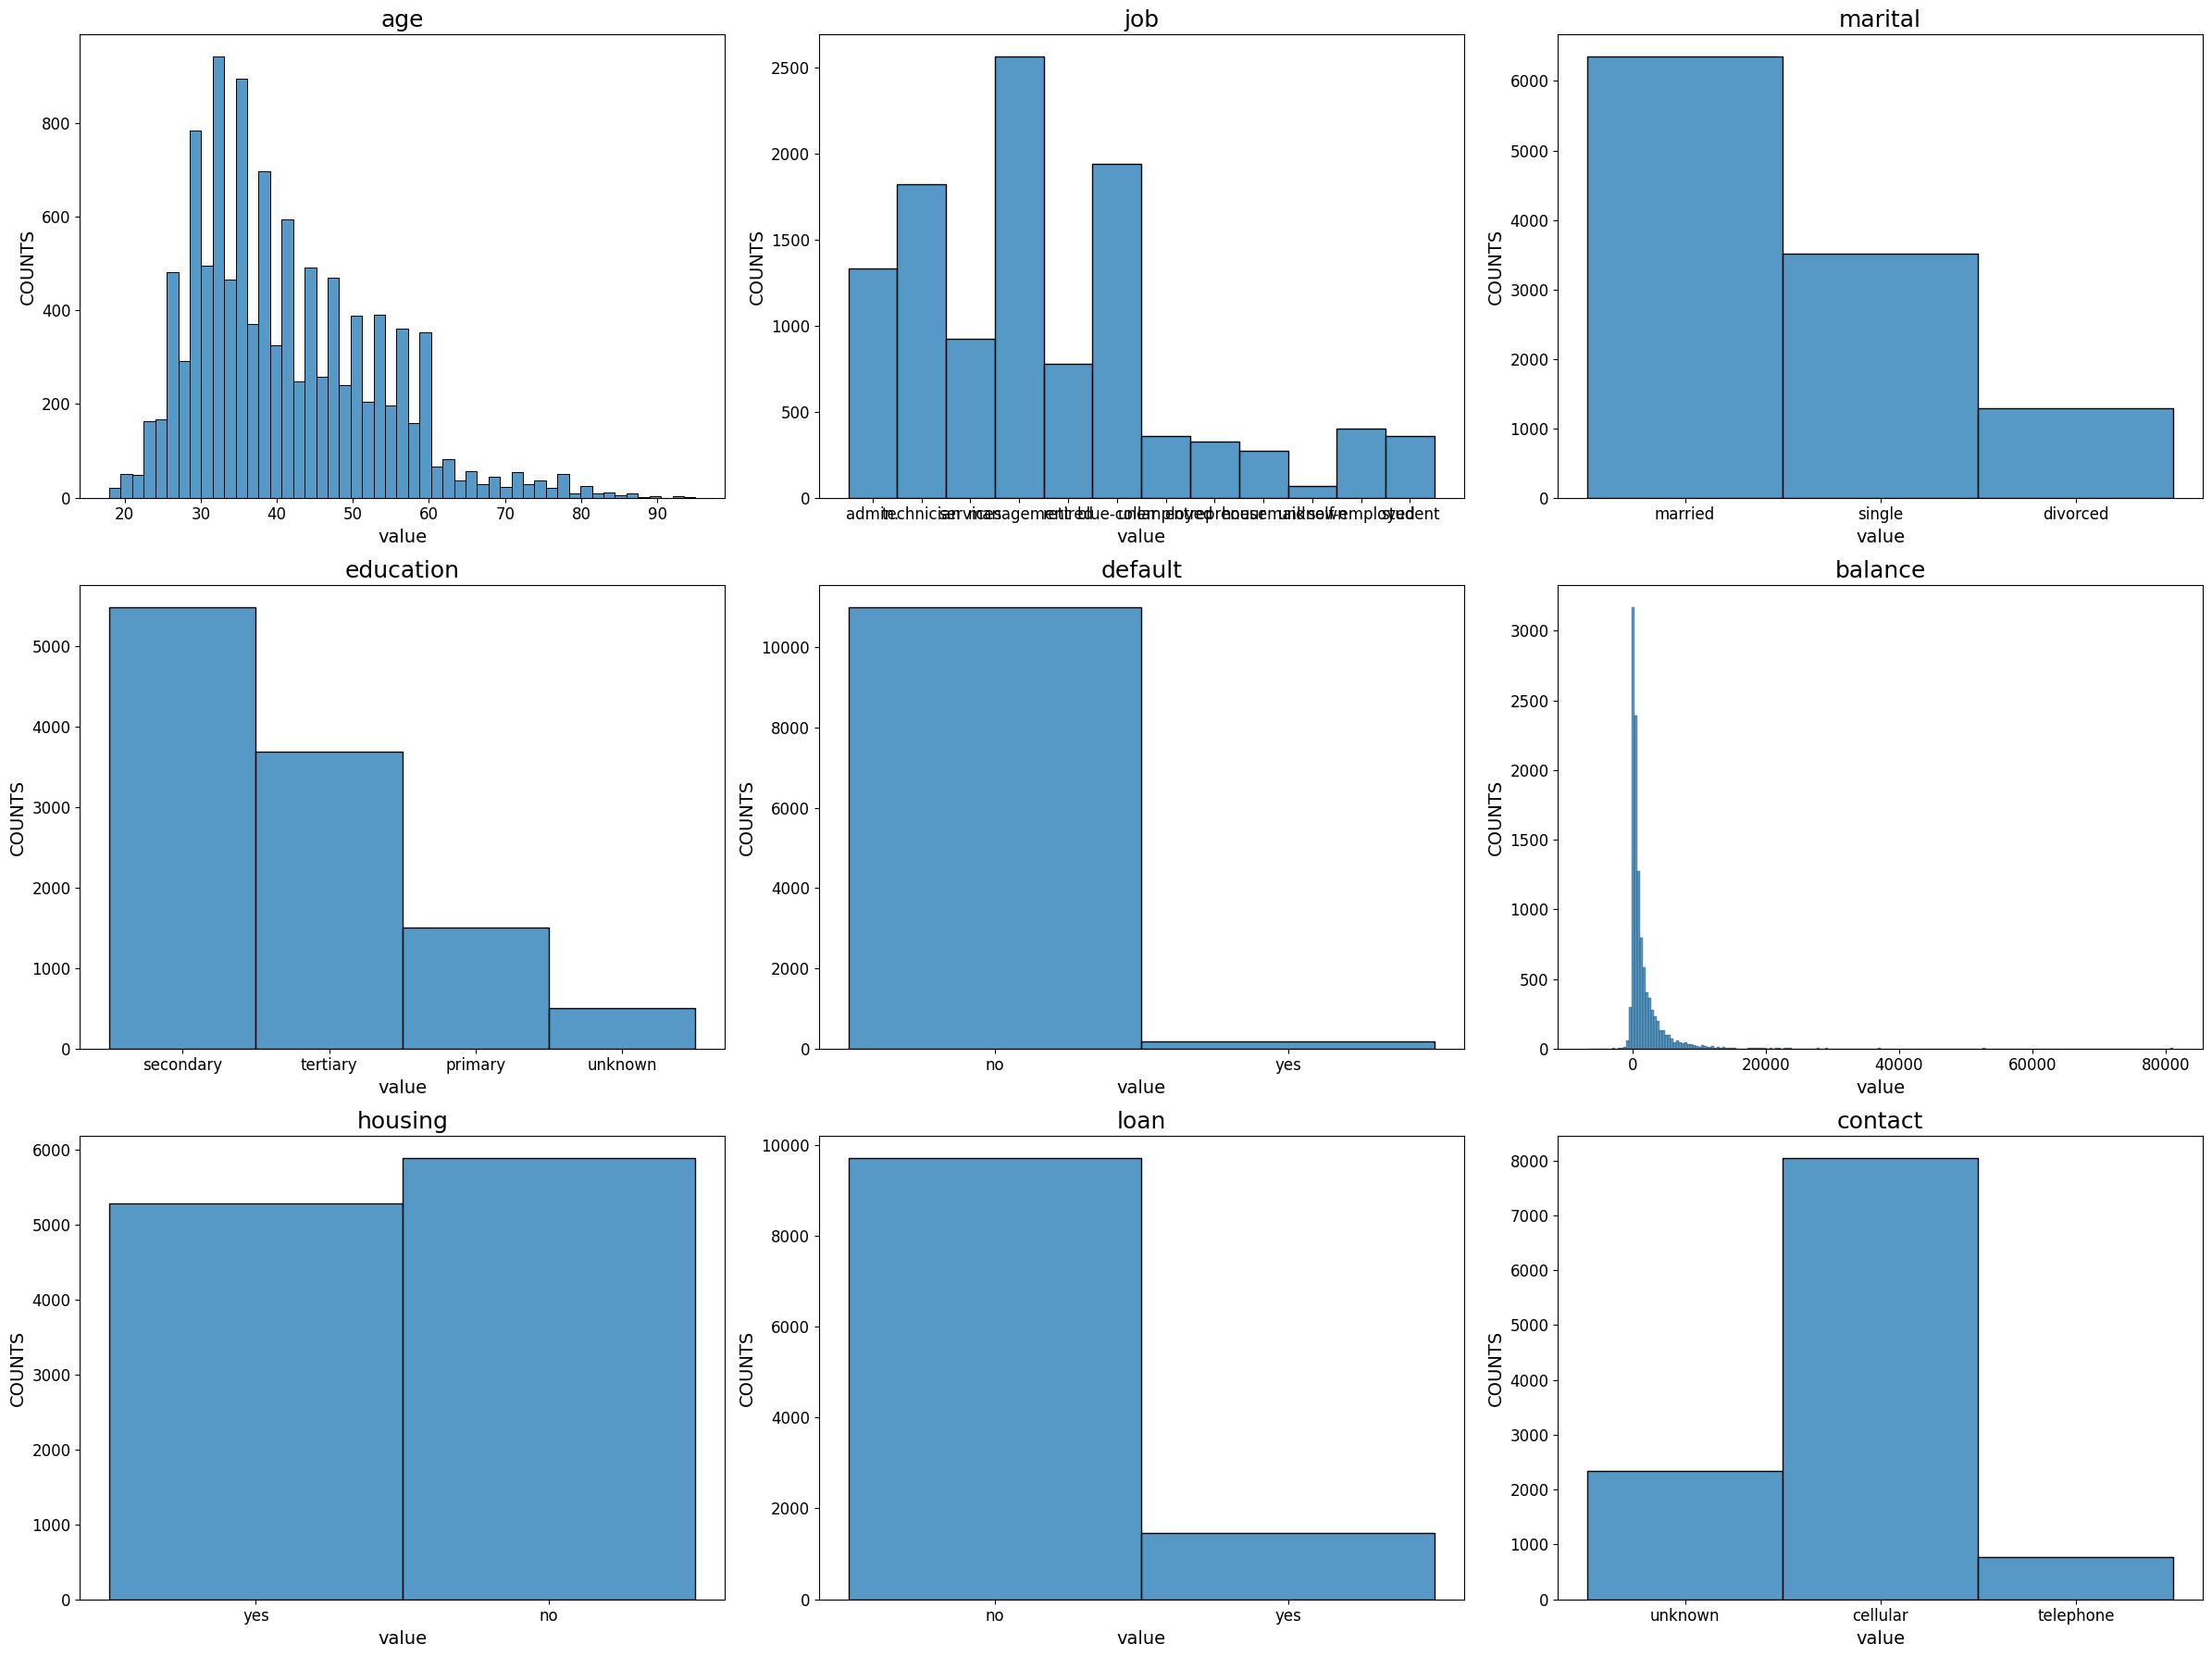

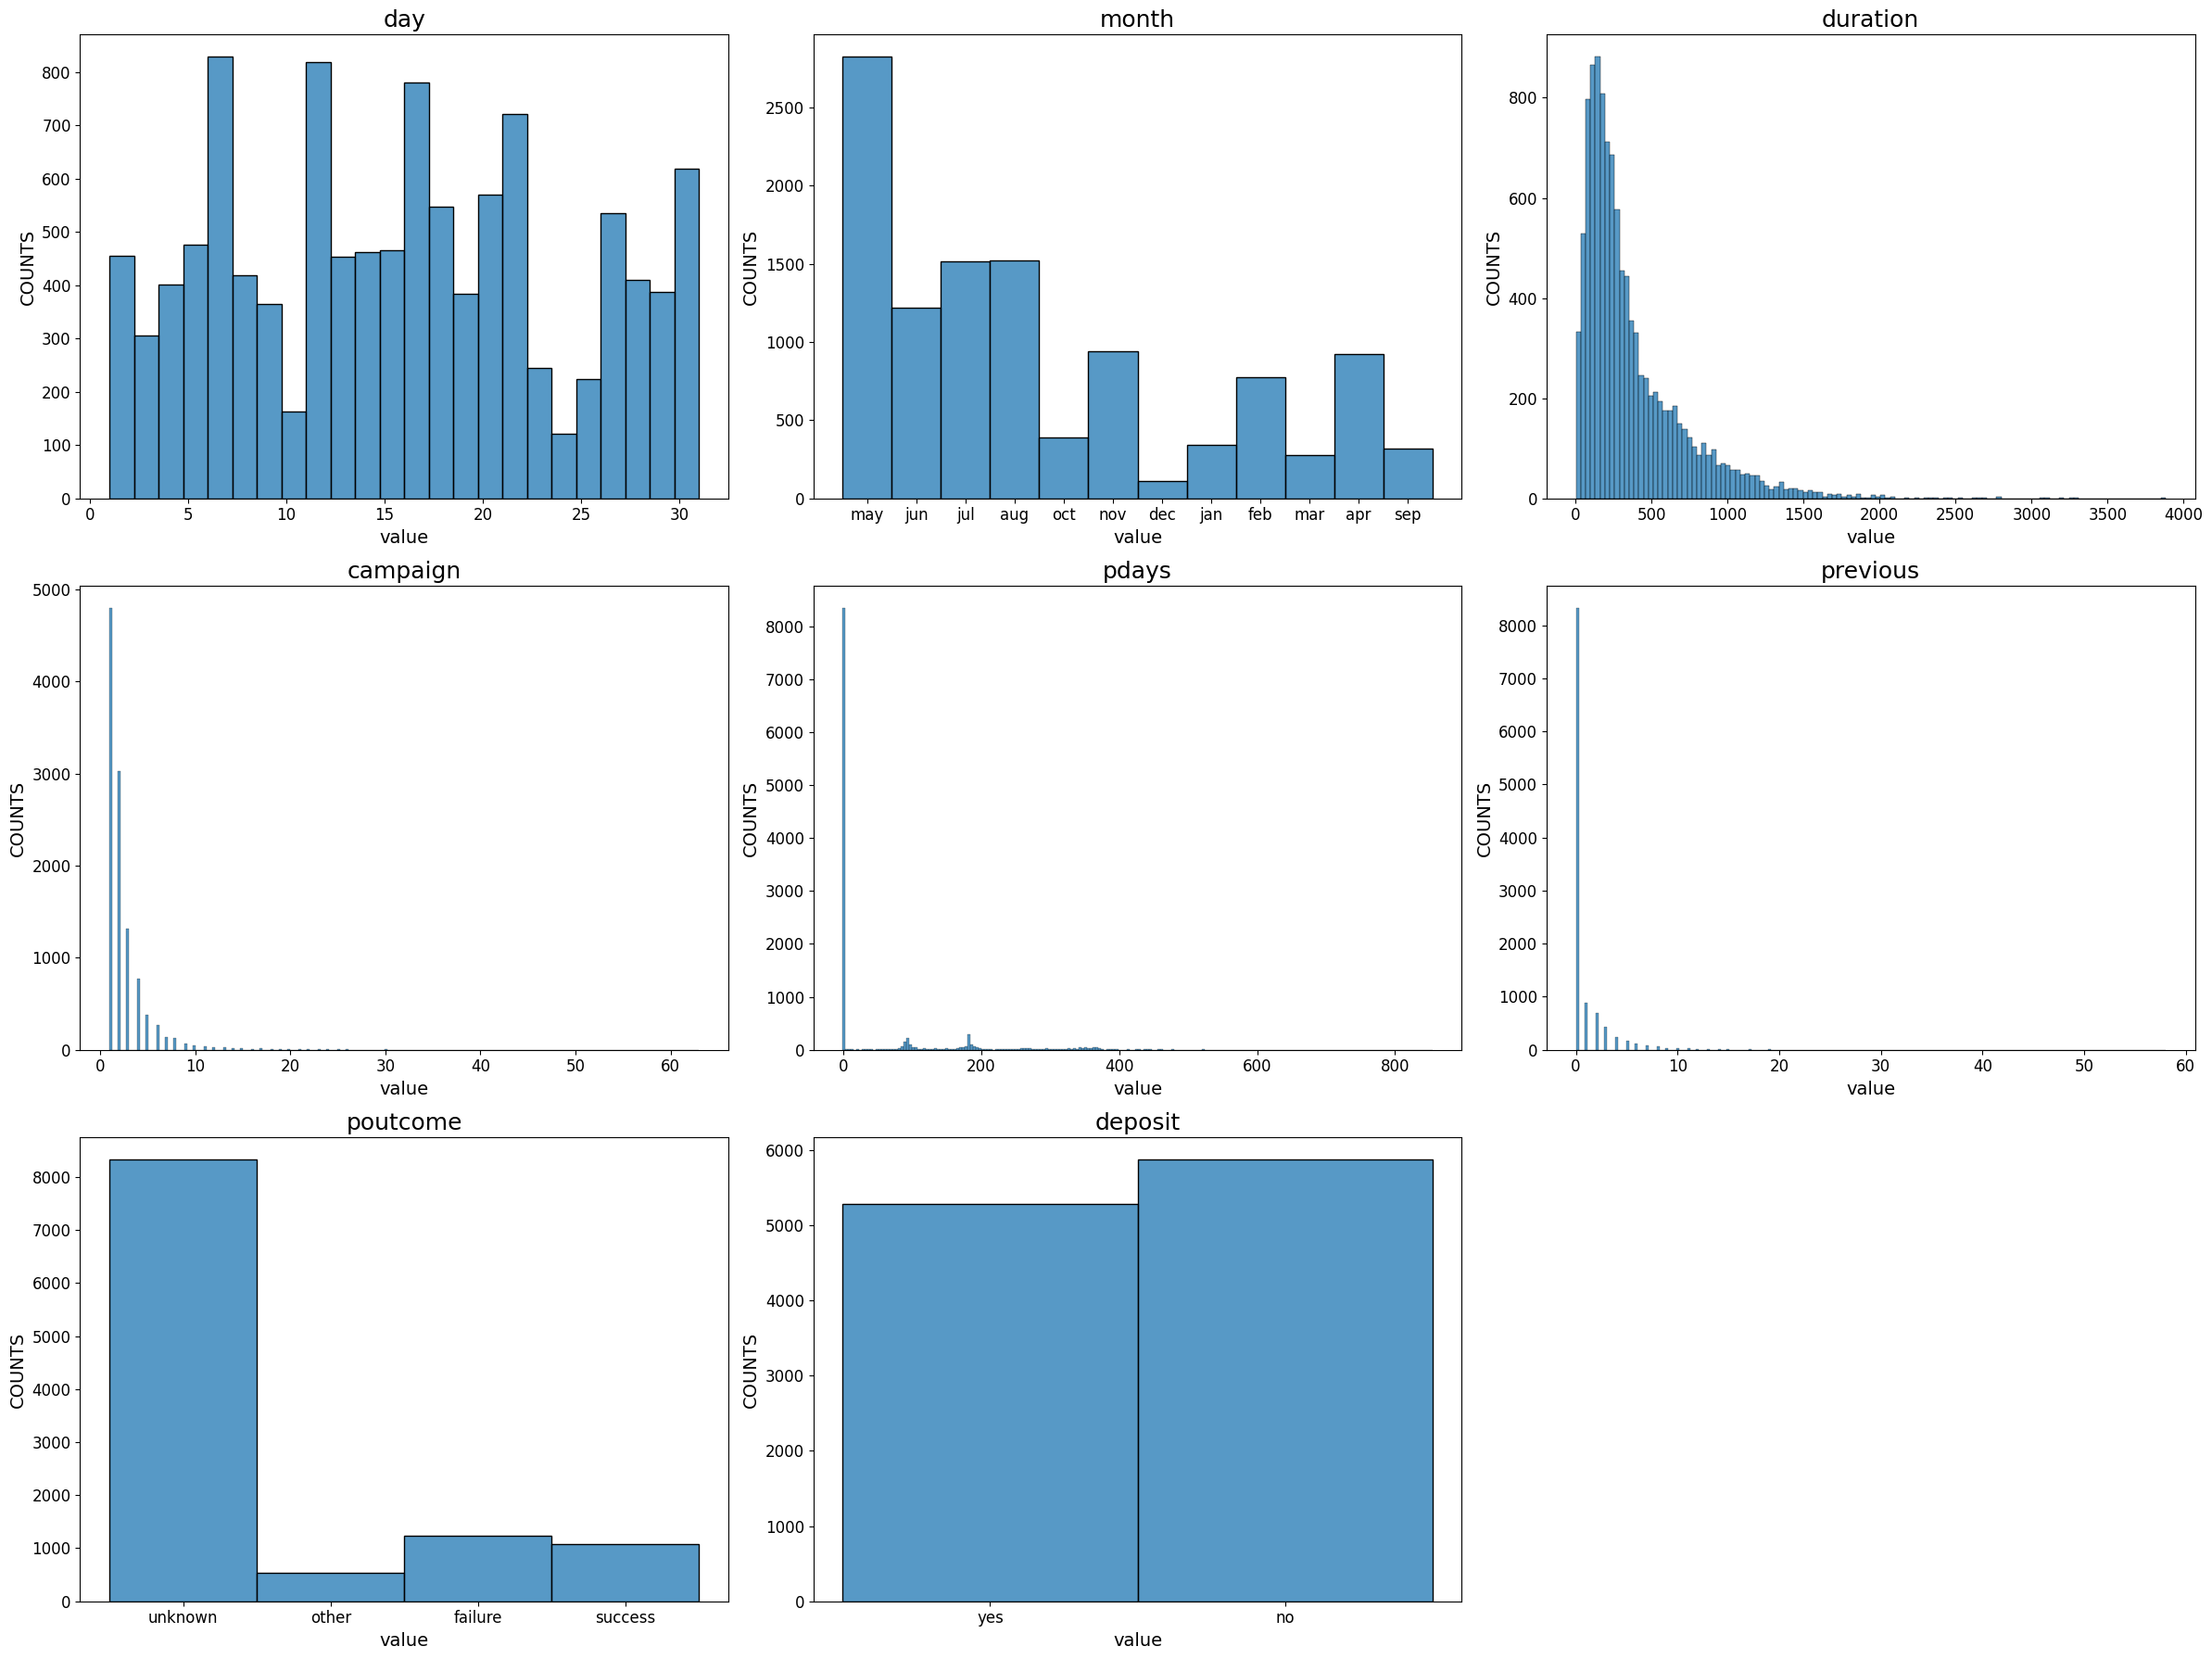

In [5]:
get_hist_plots(df)

## Графики "ящик с усами" (boxplot)


Boxplot (ящики с усами) были построены для анализа распределения числовых признаков.
Данный тип графика позволяет:

1.	Оценить центральные тенденции (медиану) признаков.
2.	Проанализировать разброс значений (межквартильный размах).
3.	Выявить выбросы и экстремальные значения.



Boxplot показал наличие выбросов во всех признаках, за исключением признака day.
Для некоторых признаков наблюдается сильная правосторонняя асимметрия (длинный верхний хвост). Это говорит о наличии небольшого числа клиентов с очень большими значениями признаков, что характерно для финансовых и поведенческих данных.




Итог

Построение boxplot позволило визуально сравнить распределения числовых, выявить выбросы и оценить потенциальную информативность признаков для задачи бинарной классификации.

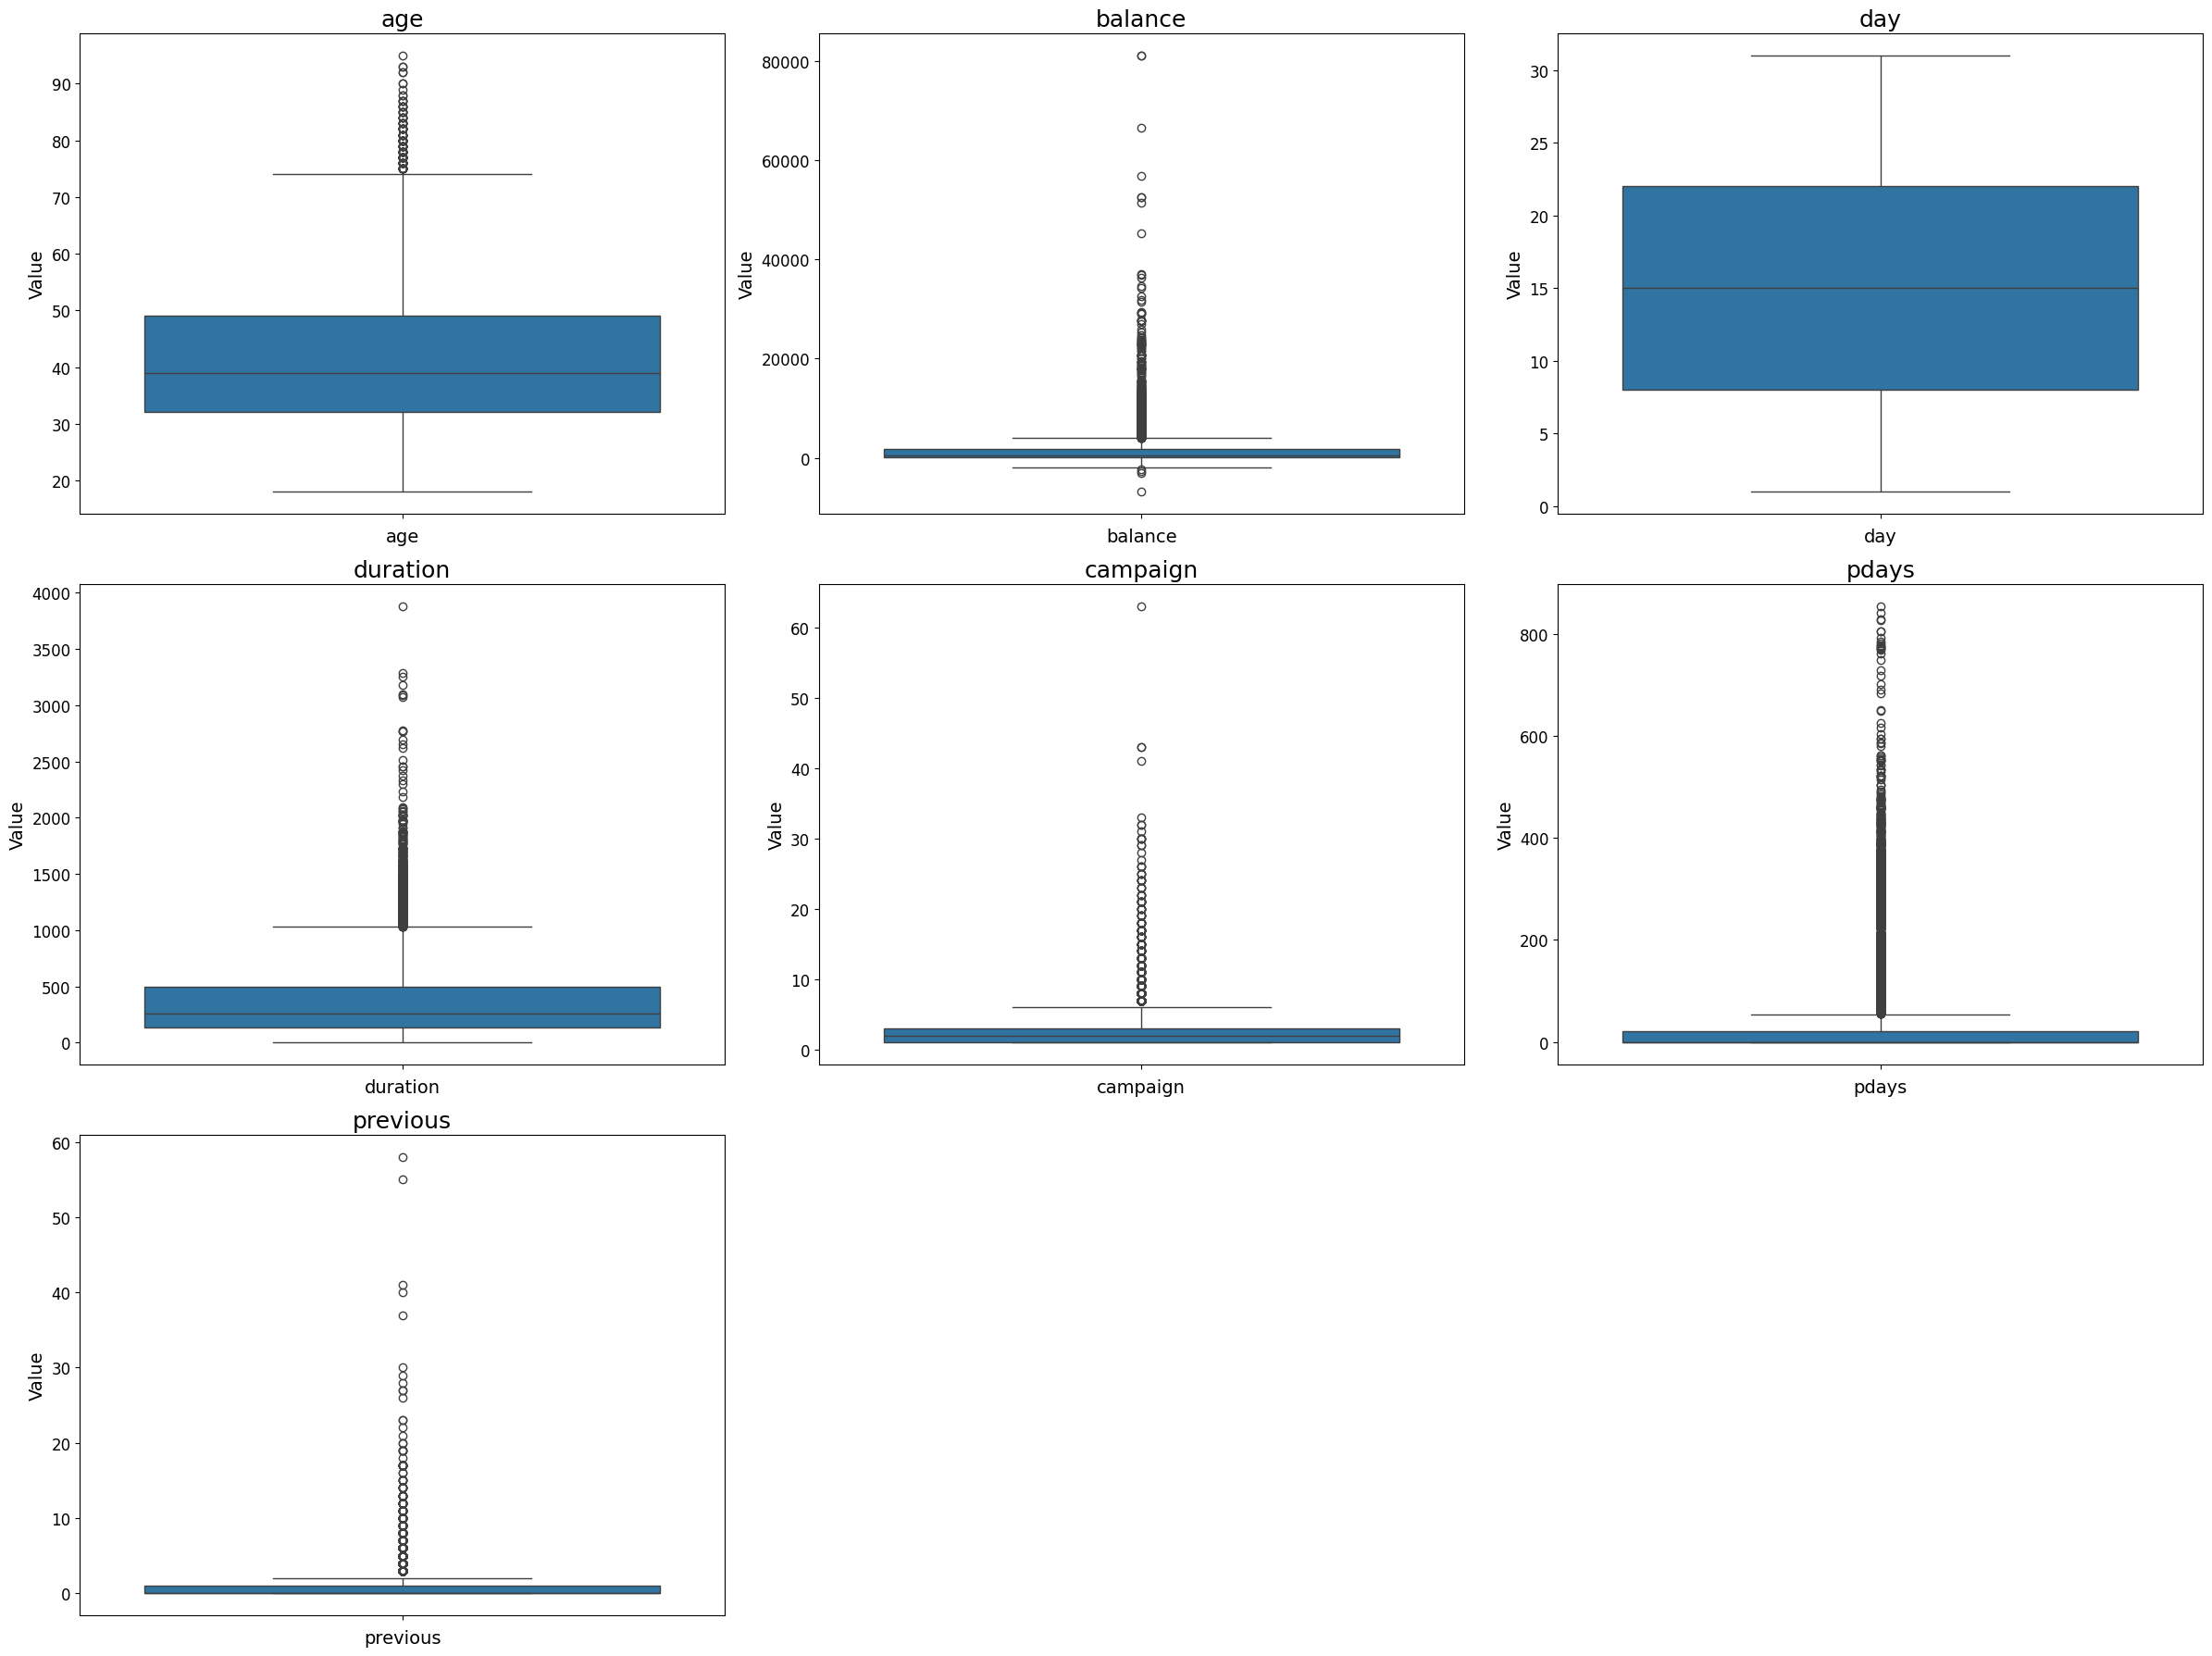

In [6]:
get_box_plots(df)

## Матрица корреляции

Матрица корреляции показывает силу и направление линейной связи между переменнными
Диапазон значений от -1 до 1. 

1 - сильная прямая связь (признаки растут вместе)

-1 - сильная обратная связь (один признак растет другой падает)

0 - взаимосвязи нет

По матрице можно сделать вывод, что мультиколлинеарность в наших признаках отсутствует

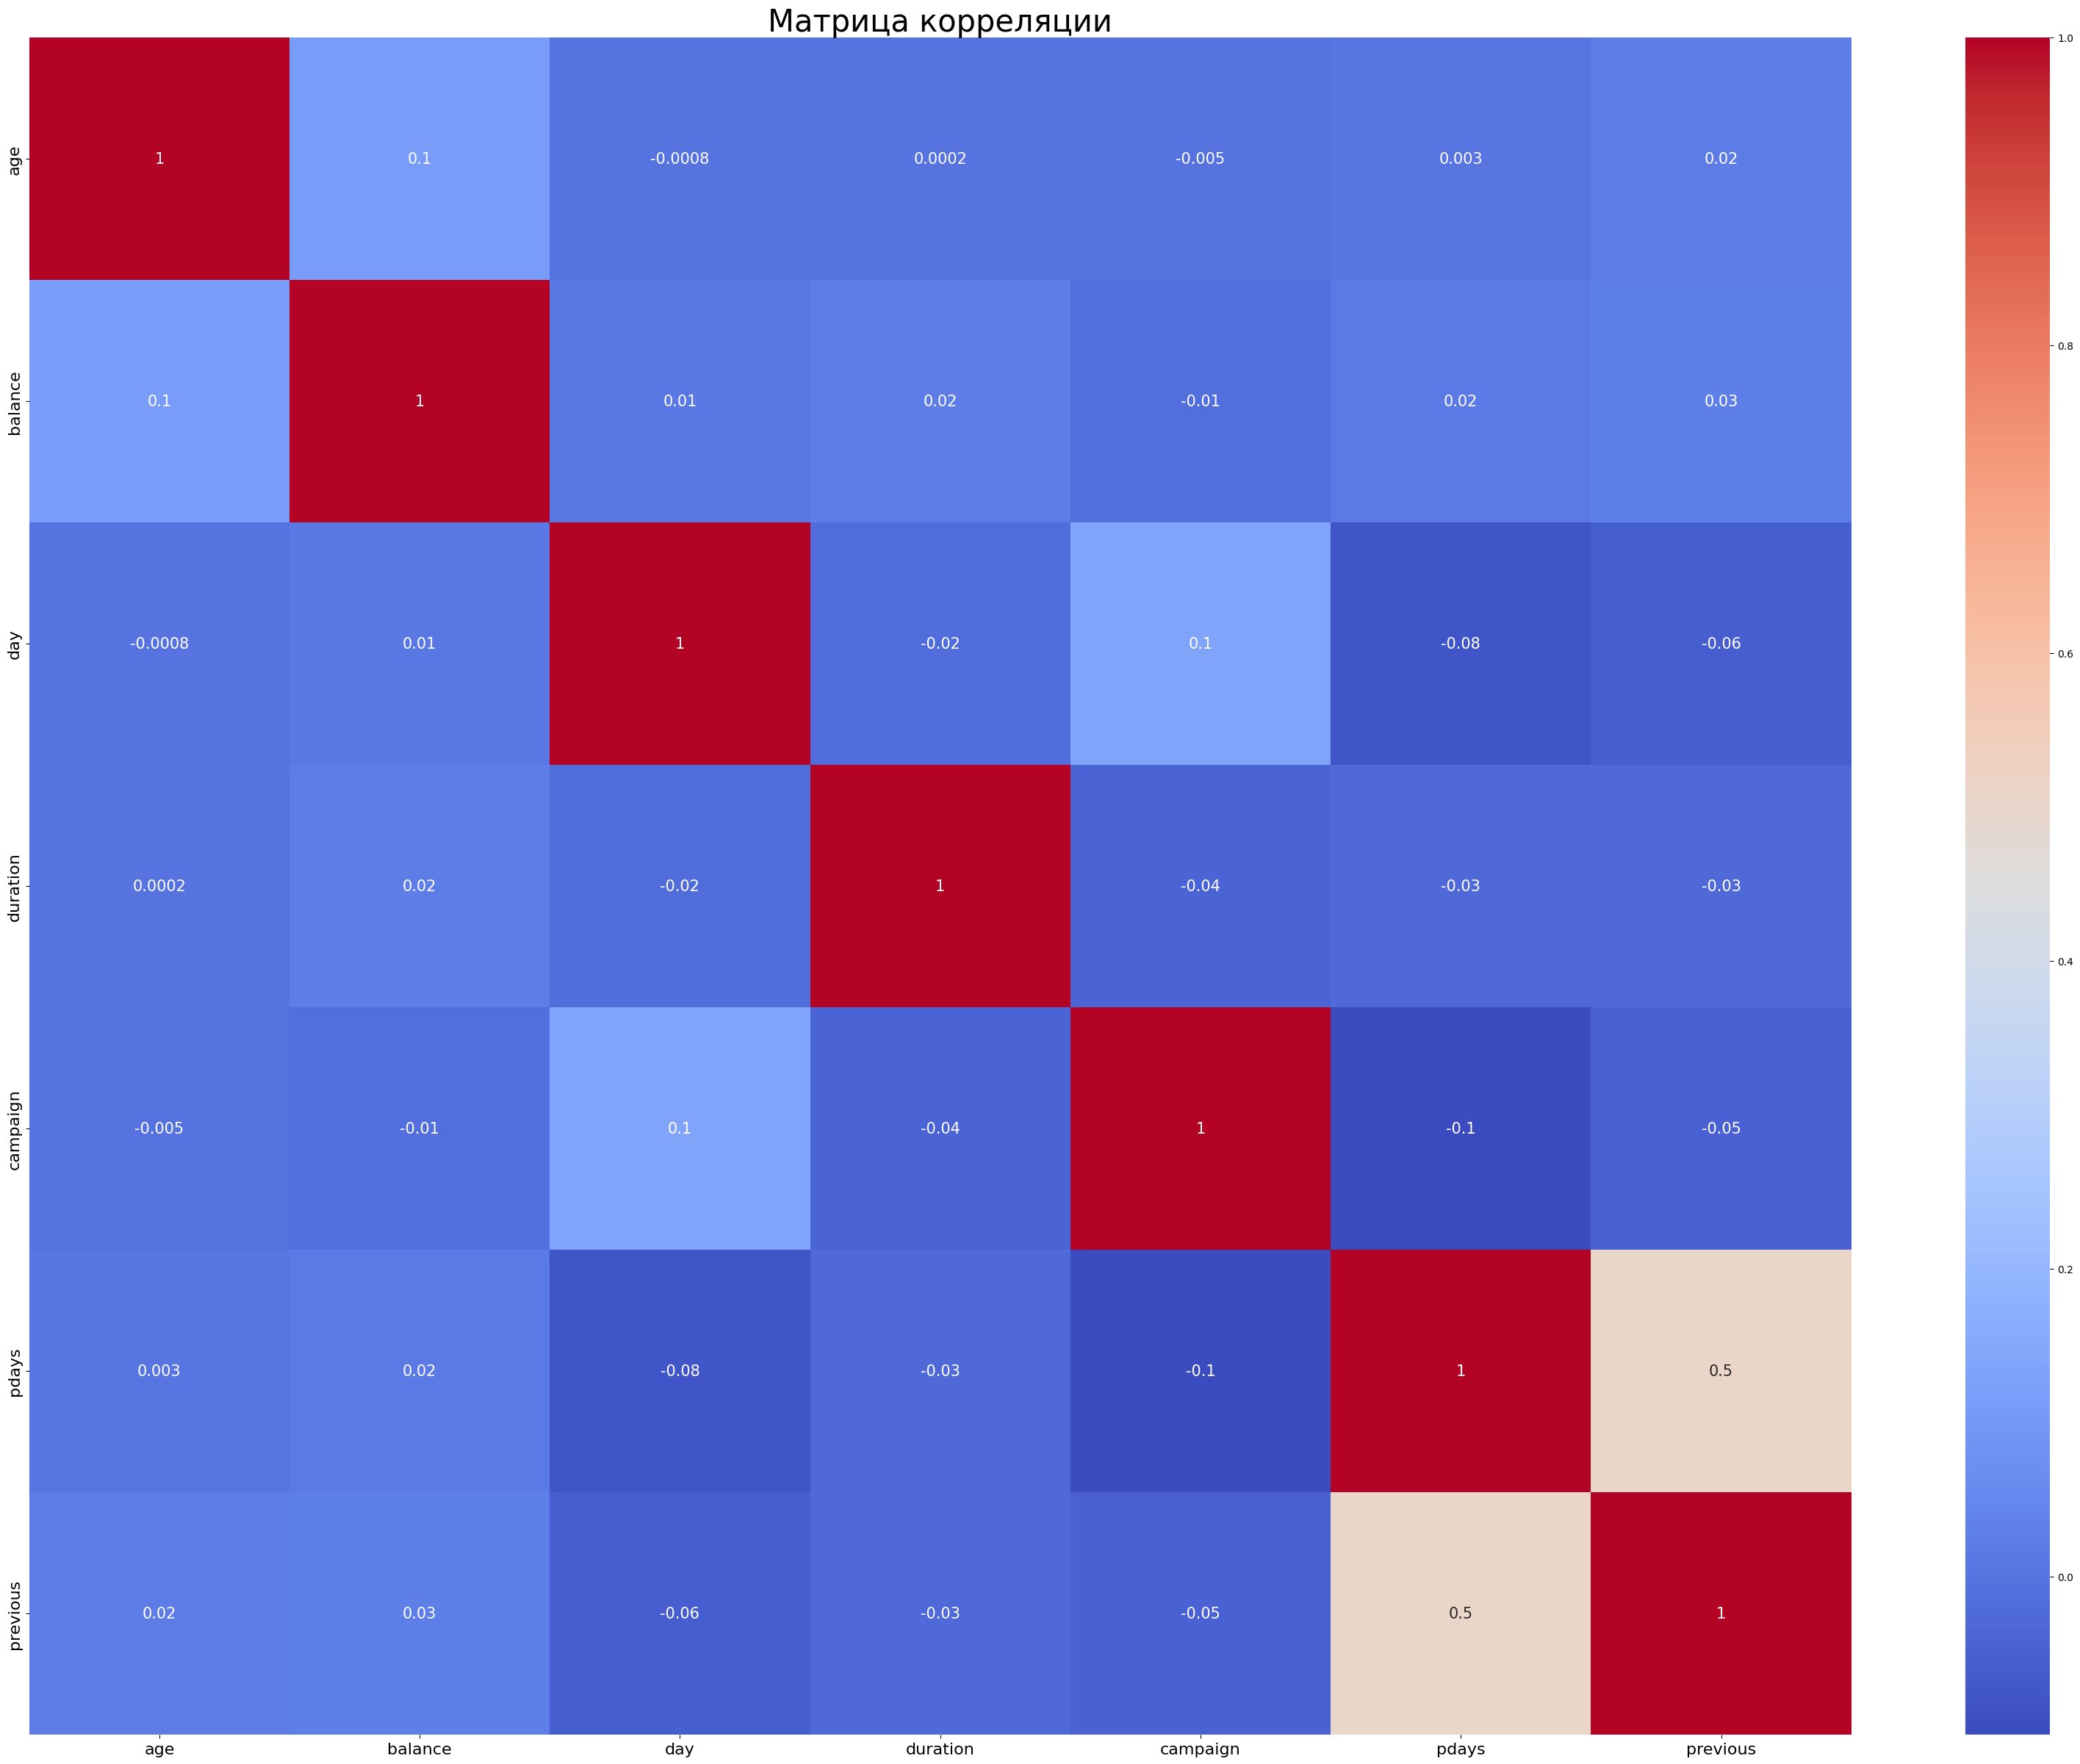

In [7]:
get_corr_matrix(df)

## Графики countplots


Графики countplot по категориальным признакам с разбиением по целевой переменной deposit были построены для анализа взаимосвязи категориальных характеристик клиентов с их откликом на целевую переменную.

Данный тип визуализации позволяет:

1.	Оценить распределение клиентов по категориям каждого признака.
2.	Сравнить количество клиентов, оформивших депозит (yes) и отказавшихся (no), внутри каждой категории.
3.	Выявить категории, ассоциированные с более высокой или низкой вероятностью отклика.
4.	Получить бизнес-инсайты о том, какие группы клиентов более склонны принимать предложение банка.

Итог

Визуальный анализ показывает, клиенты с дефолтными кредитами практически не оформляют депозит, клиенты с ипотекой менее подвержены к оформлению депозита, по сравнению с клиентами без ипотеки, клиенты с персональным кредитом гораздо реже оформляют депозит, по сравнению с клиентами без кредита

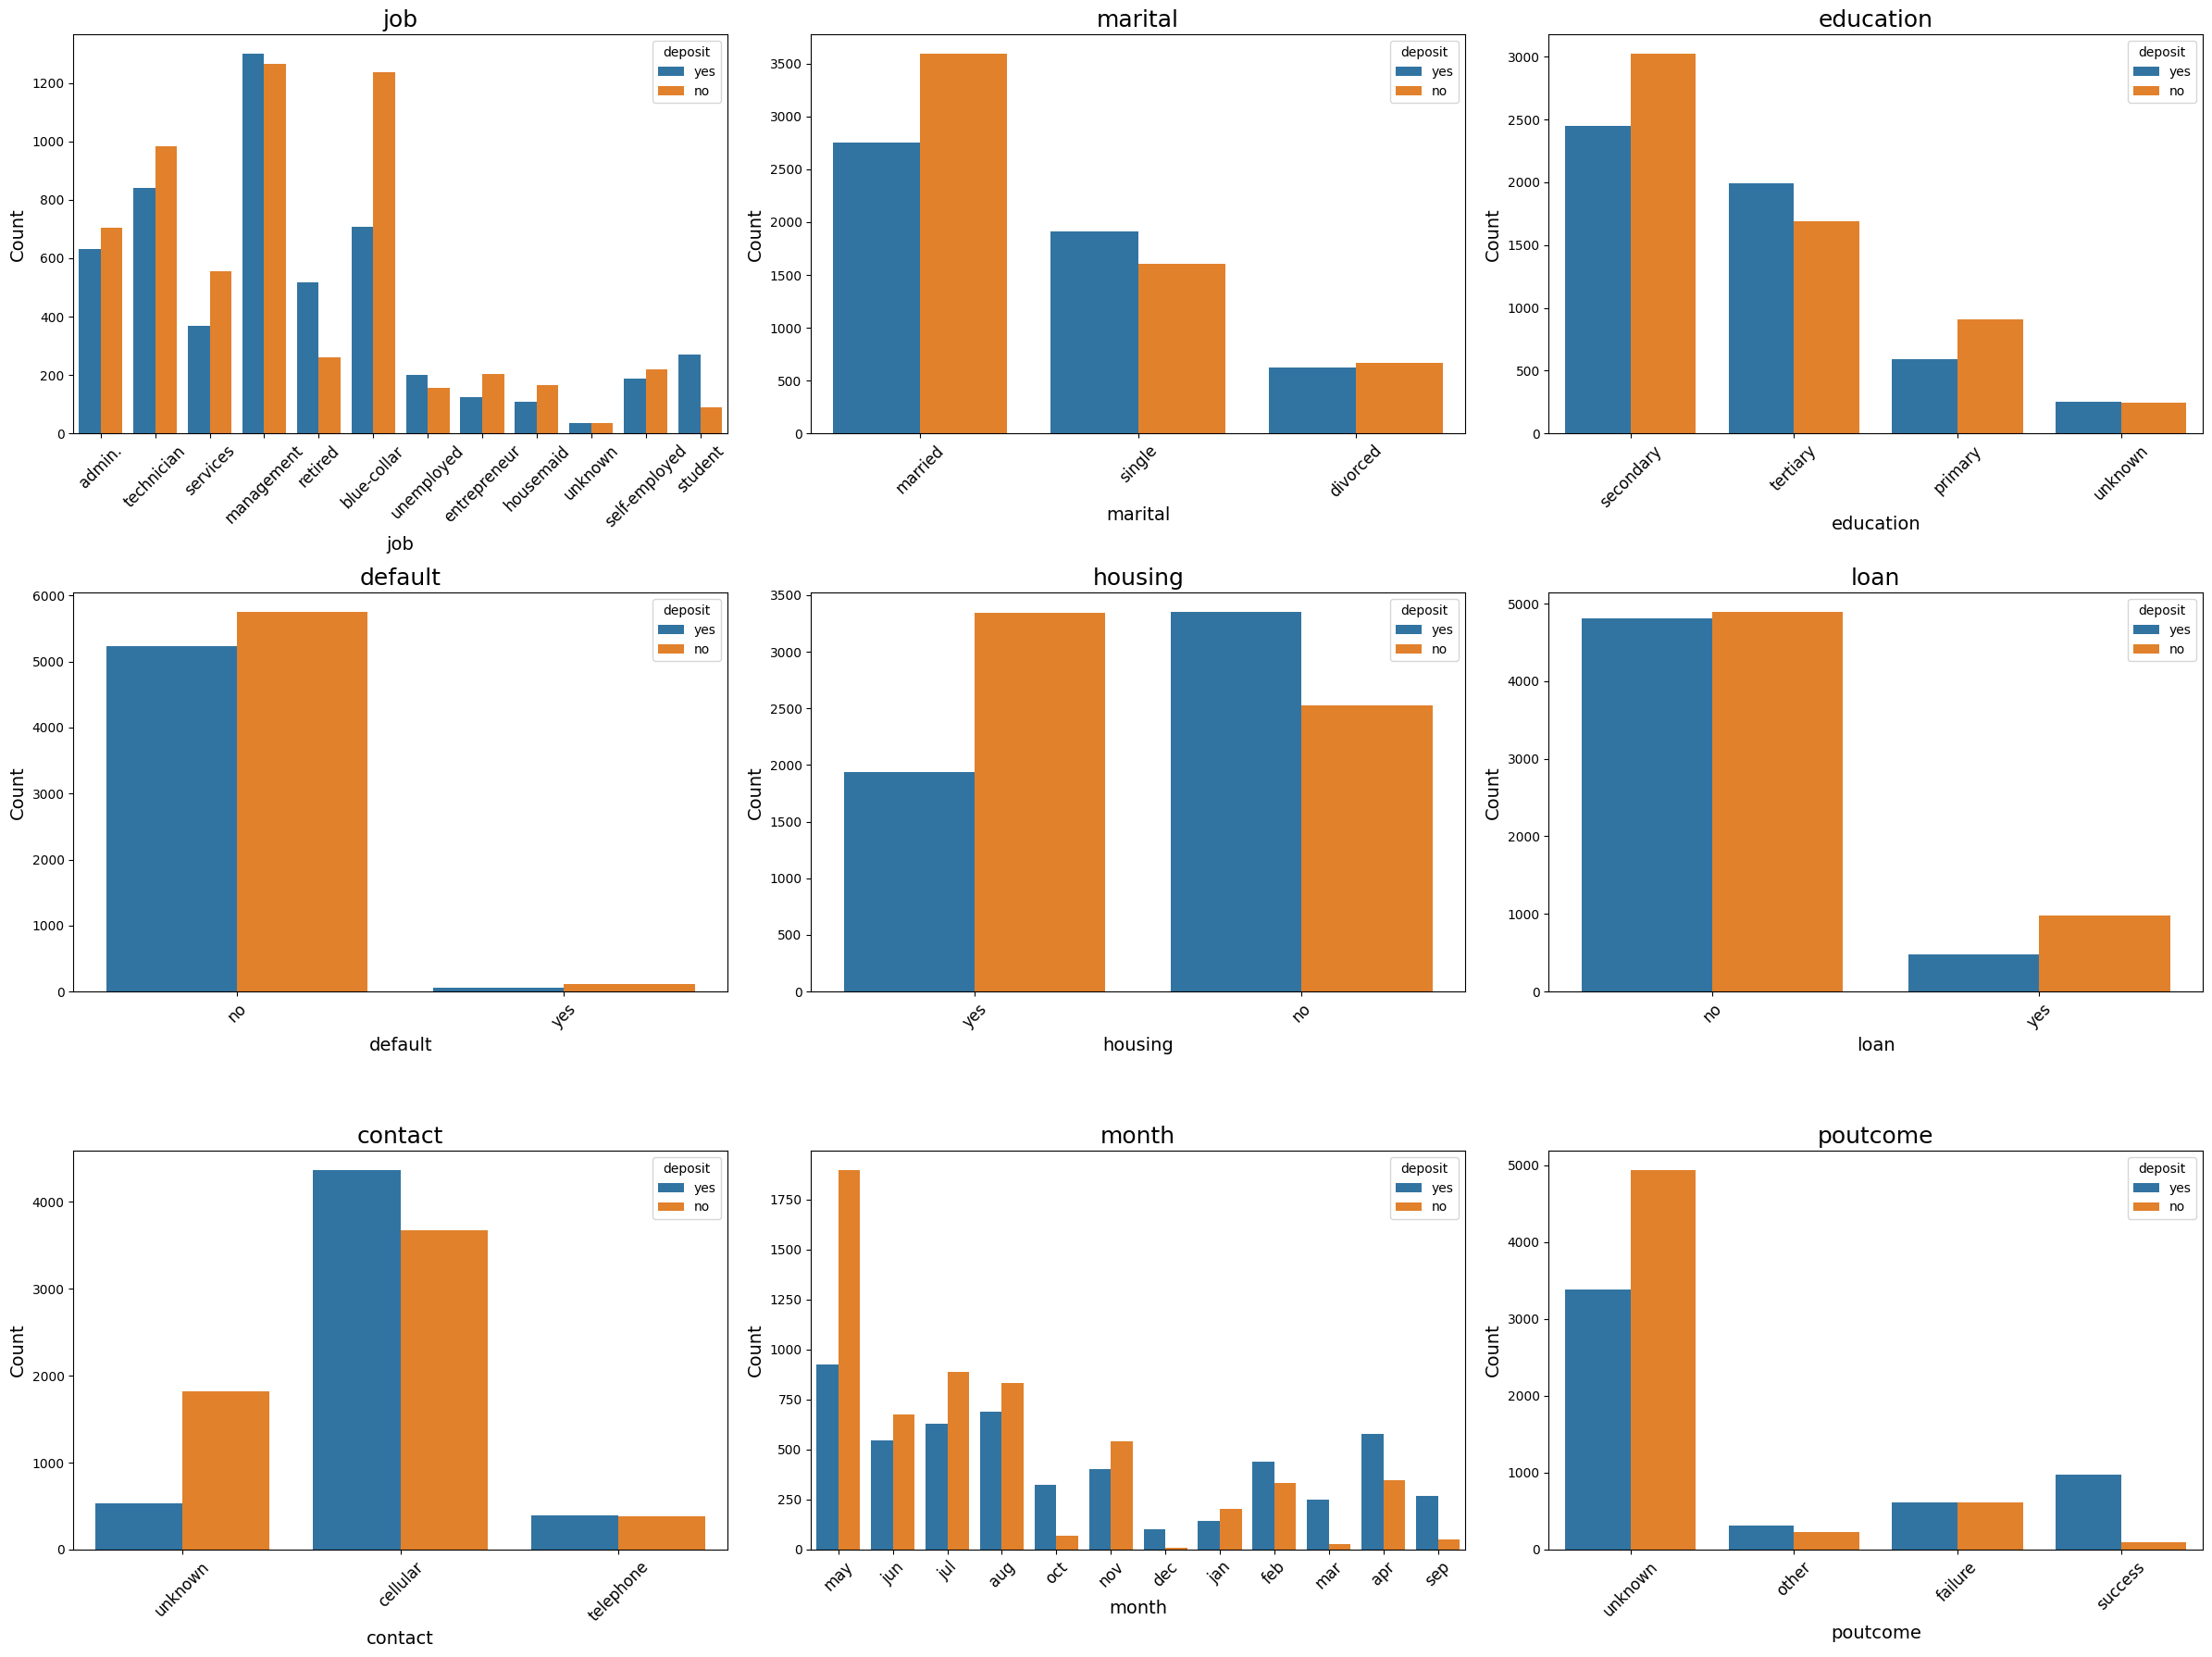

In [8]:
get_count_plot(df)

## Графики violinplot


Графики violinplot были построены для анализа распределения числовых признаков в зависимости от целевой переменной deposit.

Использование violinplot позволяет:

1.	Сравнить распределения признаков между классами yes и no.
2.	Оценить медиану и разброс значений внутри каждого класса.
3.	Проанализировать форму распределения (асимметрию, многомодальность).
4.	Выявить перекрытие распределений между классами.
5.	Определить признаки, потенциально обладающие высокой разделяющей способностью.

Итог

Визуально достаточно сложно сделать какие-либо выводы по данным графикам, за исключением признака duration(Длительность последнего звонка в секундах). Основная часть клиентов, отказавшиеся от депозита, имеют более низкое значение duration и меньшую дисперсию, по сравнению с клиентам, оформившими депозит. Но это и ожидаемо, т.к. для того, чтобы купить услугу требуется большее количество времени для консультации.


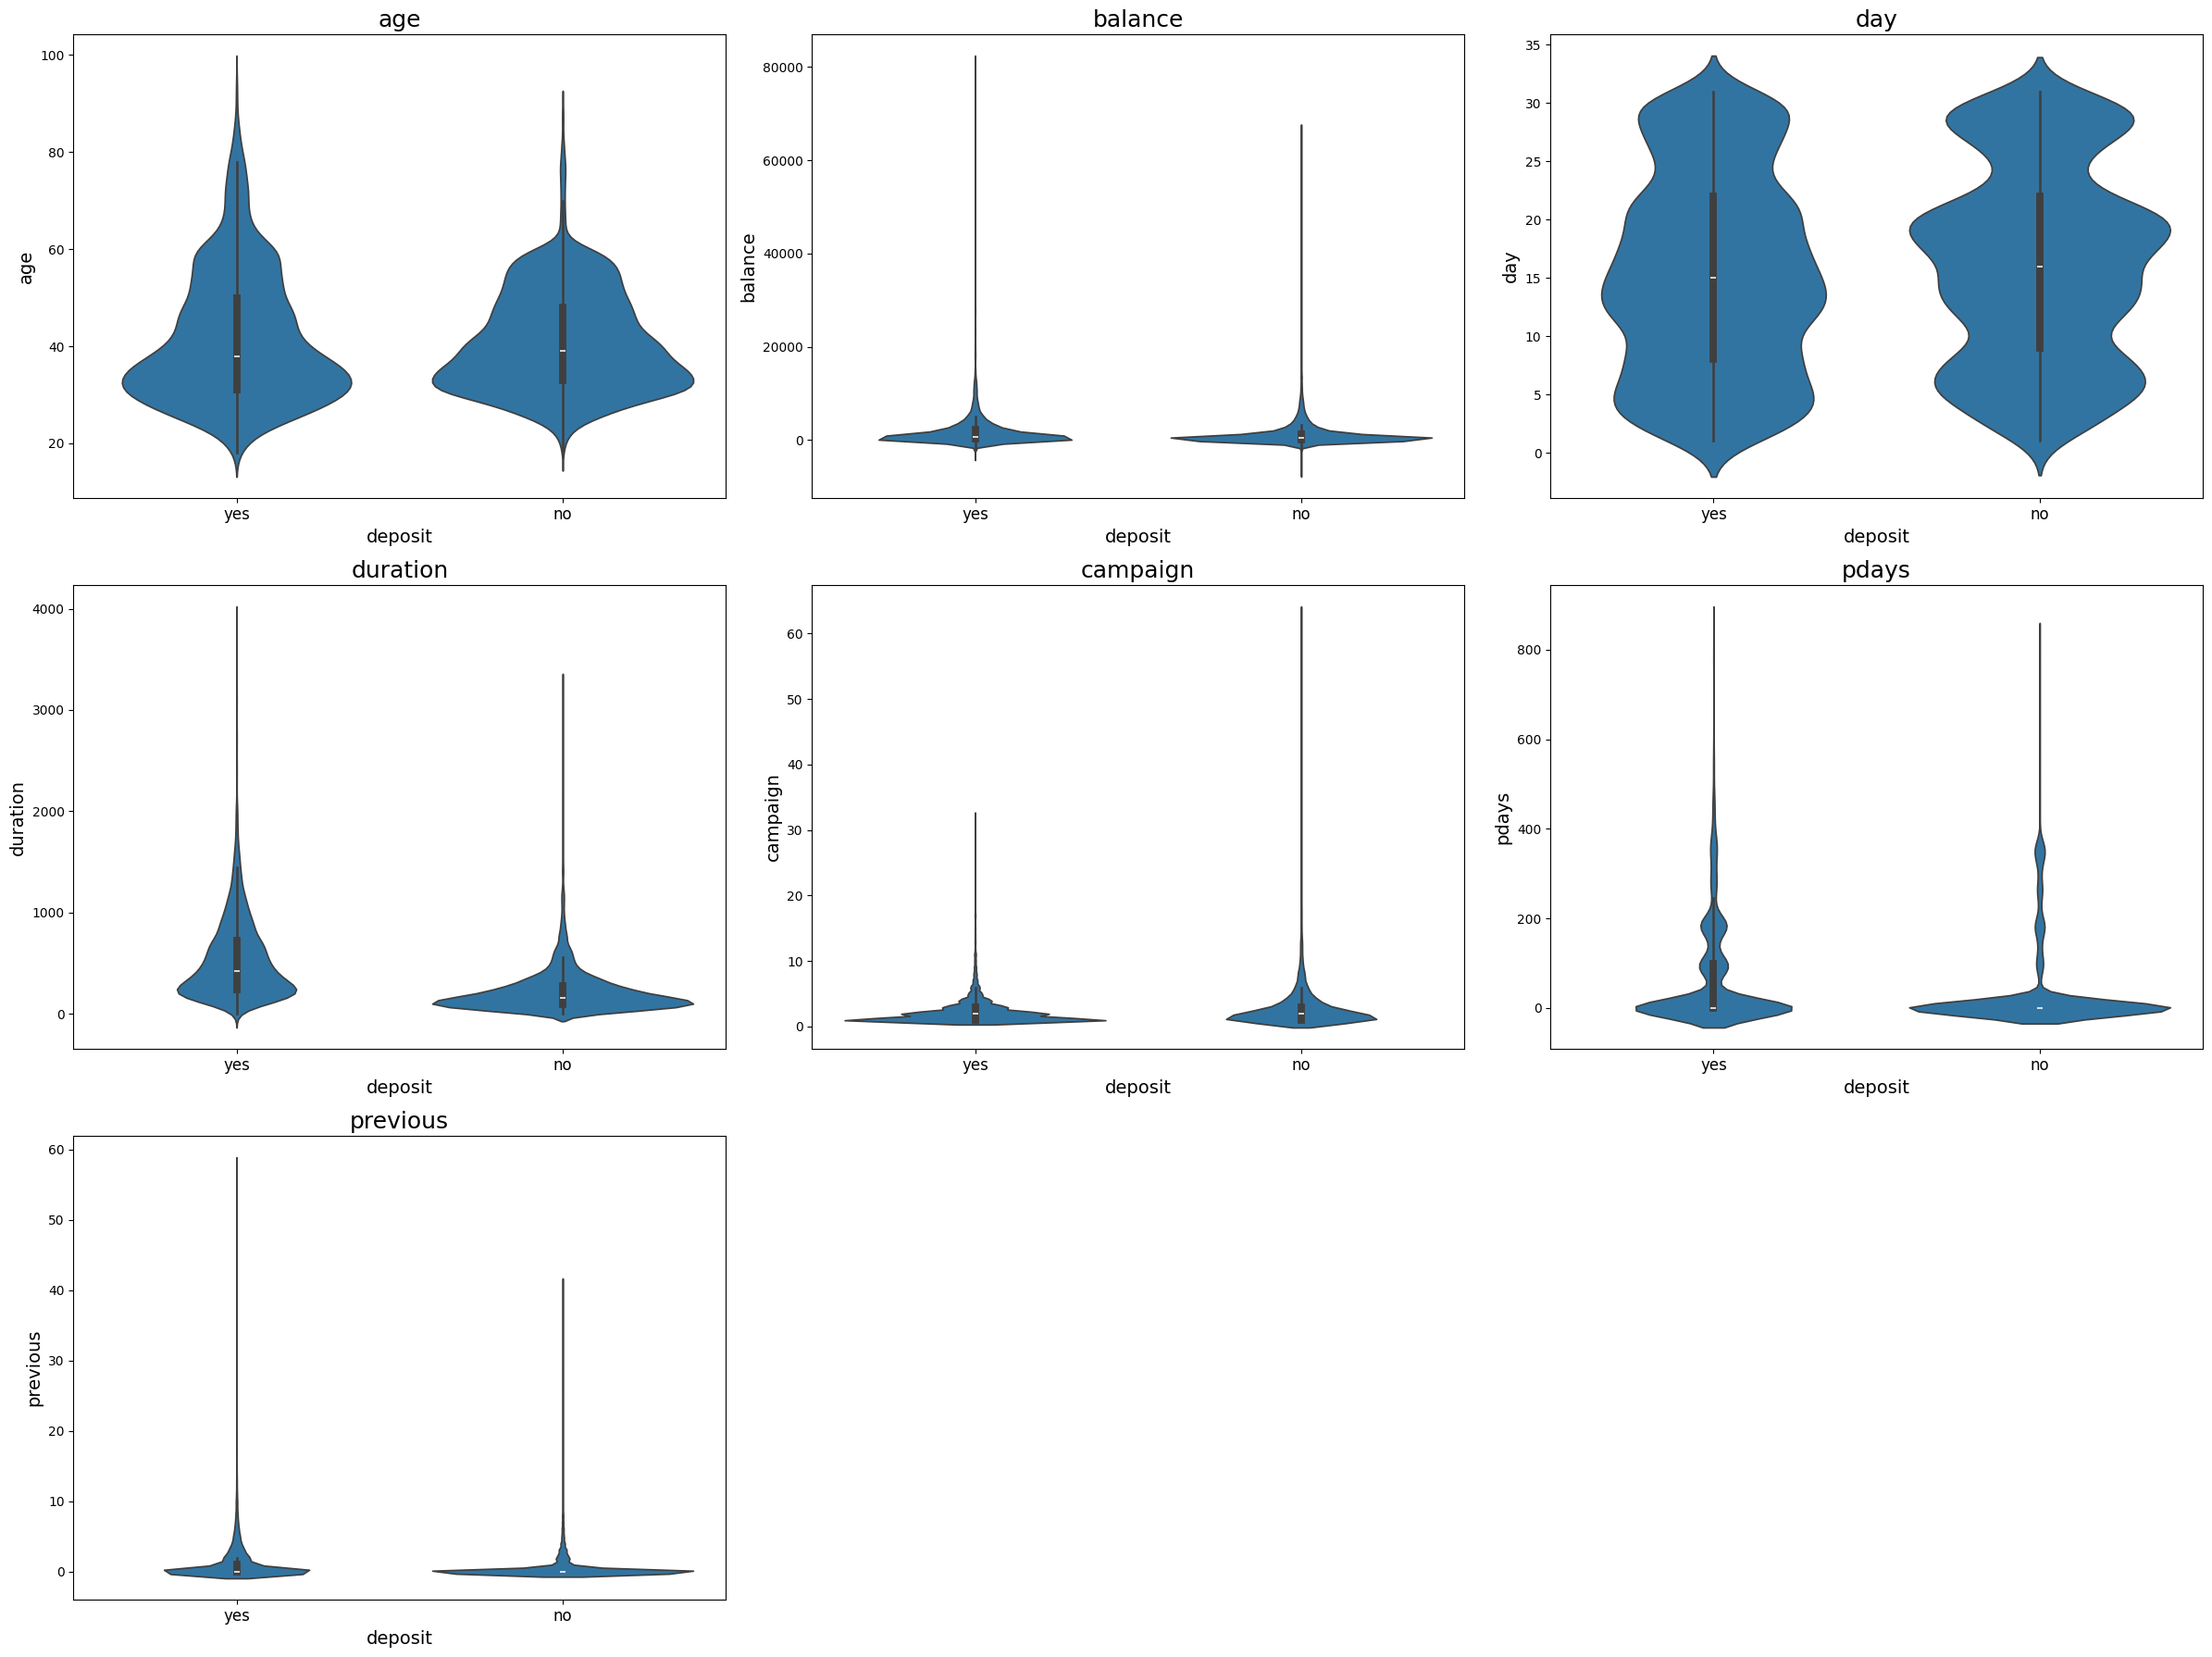

In [9]:
get_violin_plot(df)